In [1]:
# Notebook: parkinsons_voice_ml.ipynb

# 0. Imports & configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,
    confusion_matrix, r2_score, mean_squared_error, classification_report
)
from sklearn.impute import SimpleImputer

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
sns.set(context="notebook", style="whitegrid", palette="deep")

**Data Loading**

In [2]:
# 1. Load dataset

# Direct URL to a maintained mirror
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/parkinsons.data"
df = pd.read_csv(url)

# Inspect
print("Shape:", df.shape)
df.head()

Shape: (195, 24)


,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


**Data dictionary and target setup**

In [3]:
# 2. Identify target and features
# Common UCI columns include: 'status' (1 = PD, 0 = healthy), multiple acoustic features, and 'name'
# Confirm columns present:
df.columns.tolist()

# Drop non-feature identifiers if present
id_cols = [c for c in ["name"] if c in df.columns]
df = df.drop(columns=id_cols, errors="ignore")

# Define target
target_col = "status"  # UCI dataset uses 'status' as PD indicator
if target_col not in df.columns:
    raise ValueError("Expected 'status' column not found. Verify dataset columns.")

X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

print("Features:", X.shape[1], "Target distribution:\n", y.value_counts())

Features: 22 Target distribution:
 status
1    147
0     48
Name: count, dtype: int64


**Exploratory data analysis (EDA)**

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


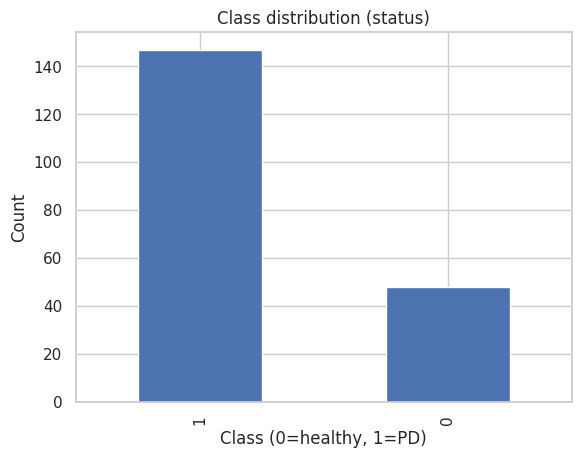

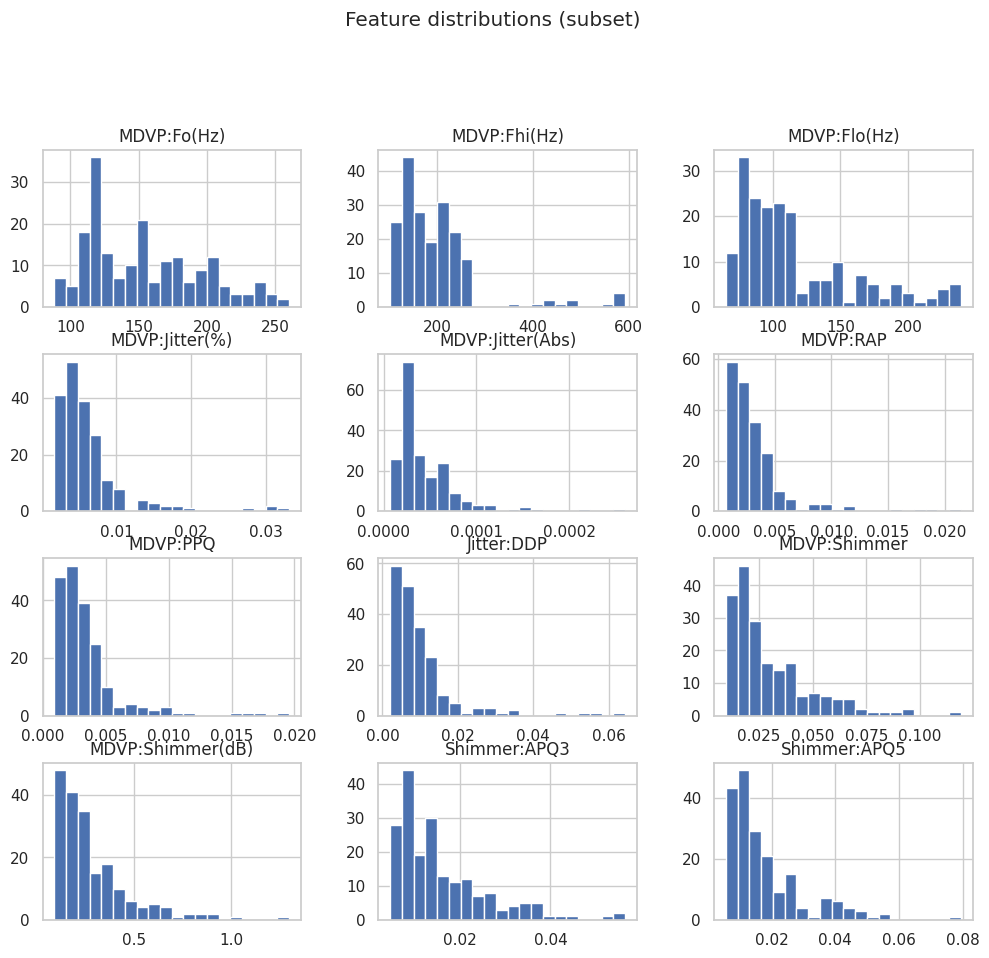

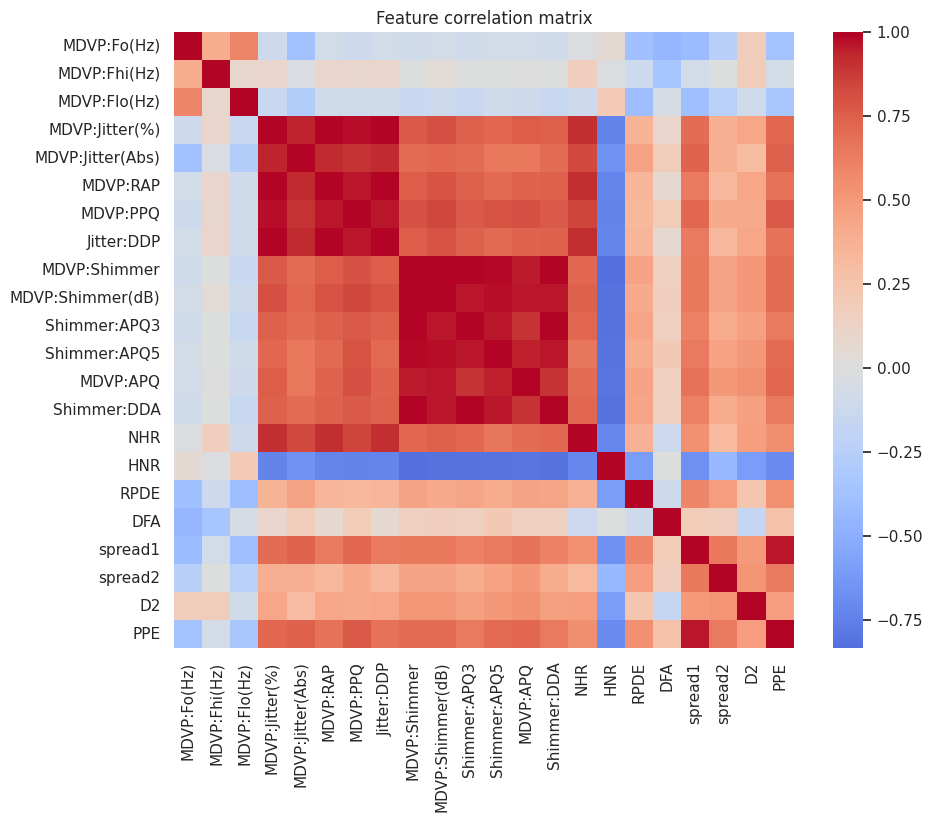

In [4]:
# 3. EDA
# Basic stats
display(X.describe().T)

# Class balance
y.value_counts().plot(kind="bar")
plt.title("Class distribution (status)")
plt.xlabel("Class (0=healthy, 1=PD)")
plt.ylabel("Count")
plt.show()

# Feature distributions (subset for readability)
subset_cols = X.columns[:12]
X[subset_cols].hist(figsize=(12, 10), bins=20)
plt.suptitle("Feature distributions (subset)", y=1.02)
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
corr = X.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.show()

**Train/test split and preprocessing**

In [5]:
# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

# 5. Preprocessing: impute missing, scale features
numeric_features = X.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ],
    remainder="drop"
)

**PCA for exploratory visualization**

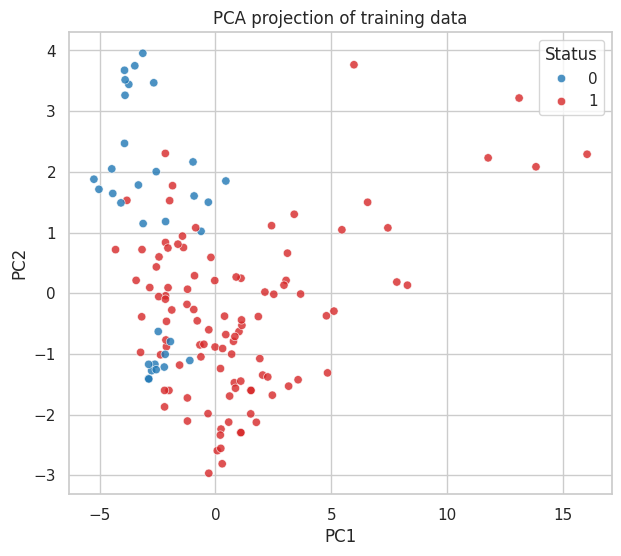

Explained variance ratio: [0.59090717 0.11534231]
Total explained (2 PCs): 0.706249471598249


In [6]:
# 6. PCA visualization
pca_vis = Pipeline(steps=[("prep", preprocess), ("pca", PCA(n_components=2, random_state=RANDOM_STATE))])
Z_train = pca_vis.fit_transform(X_train)

plt.figure(figsize=(7, 6))
sns.scatterplot(x=Z_train[:,0], y=Z_train[:,1], hue=y_train, palette={0: "tab:blue", 1: "tab:red"}, alpha=0.8)
plt.title("PCA projection of training data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Status")
plt.show()

# Variance explained
pca_model = pca_vis.named_steps["pca"]
print("Explained variance ratio:", pca_model.explained_variance_ratio_)
print("Total explained (2 PCs):", pca_model.explained_variance_ratio_.sum())

**Logistic regression: pipeline, CV, tuning, and evaluation**

LogReg CV ROC-AUC: [0.966 0.807 0.871 0.992 0.865] Mean: 0.9
Best params: {'clf__C': 1.0, 'clf__solver': 'lbfgs'}
Best CV ROC-AUC: 0.905

Classification report:
               precision    recall  f1-score   support

           0      0.688     0.733     0.710        15
           1      0.907     0.886     0.897        44

    accuracy                          0.847        59
   macro avg      0.797     0.810     0.803        59
weighted avg      0.851     0.847     0.849        59

Accuracy: 0.847
Precision: 0.907
Recall: 0.886
F1: 0.897
ROC-AUC: 0.883


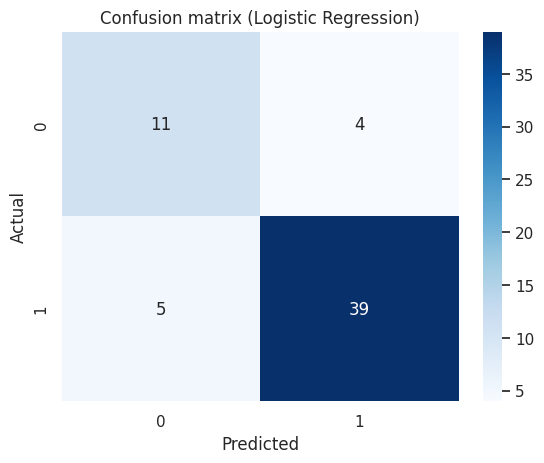

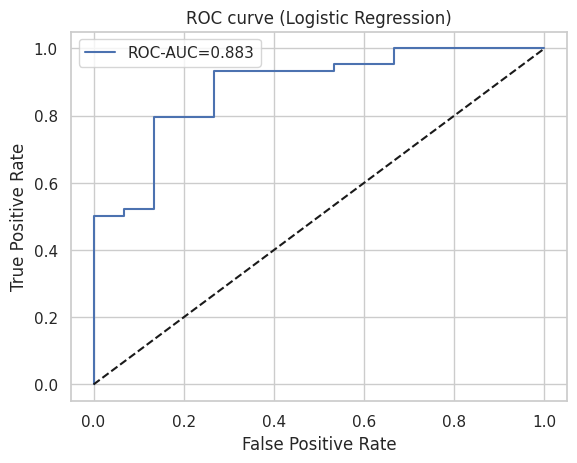

,feature,coef
18,spread1,1.115742
12,MDVP:APQ,0.954246
21,PPE,0.898042
20,D2,0.707711
5,MDVP:RAP,0.398004
7,Jitter:DDP,0.395785
15,HNR,0.370920
11,Shimmer:APQ5,0.347892
9,MDVP:Shimmer(dB),0.319691
8,MDVP:Shimmer,0.301438


In [7]:
# 7. Logistic Regression pipeline
log_reg = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=500, penalty="l2", solver="liblinear", random_state=RANDOM_STATE))
])

# 7a. Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(log_reg, X_train, y_train, cv=cv, scoring="roc_auc")
print("LogReg CV ROC-AUC:", np.round(cv_scores, 3), "Mean:", np.round(cv_scores.mean(), 3))

# 7b. Grid search for C and solver
param_grid = {
    "clf__C": [0.01, 0.1, 1.0, 10.0],
    "clf__solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(log_reg, param_grid, cv=cv, scoring="roc_auc", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", np.round(grid.best_score_, 3))

# 7c. Final model evaluation on test
best_log = grid.best_estimator_
y_pred = best_log.predict(X_test)
y_proba = best_log.predict_proba(X_test)[:, 1]

print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))
print("Accuracy:", np.round(accuracy_score(y_test, y_pred), 3))
print("Precision:", np.round(precision_score(y_test, y_pred), 3))
print("Recall:", np.round(recall_score(y_test, y_pred), 3))
print("F1:", np.round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", np.round(roc_auc_score(y_test, y_proba), 3))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC curve
fpr, tpr, th = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"ROC-AUC={roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0,1], [0,1], "k--")
plt.title("ROC curve (Logistic Regression)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# 7d. Coefficients (interpretability)
# Extract standardized coefficients via pipeline step
coeffs = best_log.named_steps["clf"].coef_.ravel()
feature_names = numeric_features  # after StandardScaler, order preserved by ColumnTransformer
coef_df = pd.DataFrame({"feature": feature_names, "coef": coeffs}).sort_values("coef", ascending=False)
coef_df.head(10)

**Linear regression: exploratory modeling of acoustic relationships**

Linear Regression R^2: 0.995
RMSE: 0.001


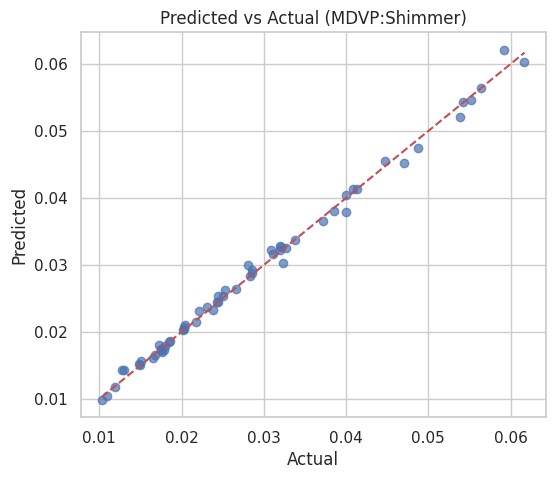

In [8]:
# 8. Linear Regression (exploratory)
# Example: Predict 'shimmer' from selected features (adjust if column names differ)
candidate_targets = [c for c in X.columns if "shimmer" in c.lower()]
if len(candidate_targets) == 0:
    print("No 'shimmer' columns found; choose another continuous target, e.g., 'MDVP:Shimmer'.")
    target_cont = X.columns[0]  # fallback
else:
    target_cont = candidate_targets[0]

# Define predictors (exclude the chosen target_cont)
X_lin = X.drop(columns=[target_cont])
y_lin = X[target_cont]

Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_lin, y_lin, test_size=0.3, random_state=RANDOM_STATE)

lin_preprocess = ColumnTransformer(
    transformers=[("num", Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), X_lin.columns.tolist())]
)

lin_reg = Pipeline(steps=[("prep", lin_preprocess), ("lr", LinearRegression())])
lin_reg.fit(Xl_train, yl_train)

yl_pred = lin_reg.predict(Xl_test)
print("Linear Regression R^2:", np.round(r2_score(yl_test, yl_pred), 3))
print("RMSE:", np.round(np.sqrt(mean_squared_error(yl_test, yl_pred)), 3))

# Pred vs Actual plot
plt.figure(figsize=(6,5))
plt.scatter(yl_test, yl_pred, alpha=0.7)
plt.title(f"Predicted vs Actual ({target_cont})")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.plot([yl_test.min(), yl_test.max()], [yl_test.min(), yl_test.max()], "r--")
plt.show()

**Sensitivity analyses and robustness checks**

In [9]:
# 9. Sensitivity: class weights for imbalance
log_reg_weights = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=500, penalty="l2", solver="liblinear", class_weight="balanced", random_state=RANDOM_STATE))
])

log_reg_weights.fit(X_train, y_train)
y_pred_w = log_reg_weights.predict(X_test)
y_proba_w = log_reg_weights.predict_proba(X_test)[:, 1]

print("Balanced Accuracy:", np.round(accuracy_score(y_test, y_pred_w), 3))
print("Balanced ROC-AUC:", np.round(roc_auc_score(y_test, y_proba_w), 3))

# 10. Sensitivity: PCA components → classifier
pca_clf = Pipeline(steps=[
    ("prep", preprocess),
    ("pca", PCA(n_components=8, random_state=RANDOM_STATE)),
    ("clf", LogisticRegression(max_iter=500, penalty="l2", solver="liblinear", random_state=RANDOM_STATE))
])

pca_scores = cross_val_score(pca_clf, X_train, y_train, cv=cv, scoring="roc_auc")
print("PCA+LogReg CV ROC-AUC:", np.round(pca_scores, 3), "Mean:", np.round(pca_scores.mean(), 3))

Balanced Accuracy: 0.695
Balanced ROC-AUC: 0.889
PCA+LogReg CV ROC-AUC: [0.973 0.807 0.871 0.992 0.865] Mean: 0.902
